## This is how Bagging/RandomForest works Internally By Using Row Sampling

#### Importing Libraries

In [285]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import random

#### Generating a Synthetic Classification Dataset

In [286]:
X , y = make_classification(n_features=5, n_informative=5, n_redundant=0, n_clusters_per_class=1)

In [287]:
df = pd.DataFrame(X , columns=['col1', 'col2' , 'col3', 'col4', 'col5'])
df['target'] = y

In [288]:
df

,col1,col2,col3,col4,col5,target
0,-1.643713,-0.236545,-1.678296,2.110738,-0.523102,1
1,-2.375461,-0.476337,-2.034966,-2.213089,-0.931895,0
2,-1.050825,-1.744124,-0.503855,0.492507,-2.952432,1
3,-1.409327,-2.369670,-0.843458,-0.833842,0.597111,1
4,0.418309,0.254353,1.014830,-0.984994,0.326898,0
...,...,...,...,...,...,...
95,-2.624380,-1.401789,-0.108643,-0.575861,-1.570415,1
96,-2.954166,1.824474,-0.805598,-0.198199,-1.668227,0
97,-2.942490,-0.205914,0.238175,-0.371184,-1.511015,1
98,-1.155139,-0.775035,-1.320919,0.981809,-0.454486,1


In [289]:
df.shape

(100, 6)

In [290]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   col1    100 non-null    float64
 1   col2    100 non-null    float64
 2   col3    100 non-null    float64
 3   col4    100 non-null    float64
 4   col5    100 non-null    float64
 5   target  100 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 4.8 KB


In [291]:
df.head()

,col1,col2,col3,col4,col5,target
0,-1.643713,-0.236545,-1.678296,2.110738,-0.523102,1
1,-2.375461,-0.476337,-2.034966,-2.213089,-0.931895,0
2,-1.050825,-1.744124,-0.503855,0.492507,-2.952432,1
3,-1.409327,-2.369670,-0.843458,-0.833842,0.597111,1
4,0.418309,0.254353,1.014830,-0.984994,0.326898,0


### Function for Row Sampling

In [292]:
def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True) #with replacement

### Function for features/columns Sampling

In [293]:
def sample_feature(df,percent):
    cols = random.sample(df.colums.tolist()[:-1], int(percent*df.shape[1]))
    return df[cols]

### Function for Combination Sampling
##### Both Rows and Columns

In [294]:
def combine_samples(df, row_percent, feature_percent):
    new_df = sample_rows(df, row_percent)
    return sample_feature(new_df, feature_percent)

### Using Row Sampling

#### `RandomForest` is collection of decision tree 
Now we will Create 3 new datasets using Row Sampling With Replacement

In [295]:
df1 = sample_rows(df,0.2)
df1

,col1,col2,col3,col4,col5,target
1,-2.375461,-0.476337,-2.034966,-2.213089,-0.931895,0
69,-1.988822,-0.601671,-2.170518,-0.493344,-2.201385,0
79,-0.704784,0.064574,-0.262360,-0.126634,-2.088989,0
46,-1.448314,-0.859228,-0.637839,-3.434080,-0.134923,0
66,0.368826,-3.455027,-2.037944,-2.552357,-0.046032,0
52,-0.430440,-0.288508,-0.550671,1.591258,-1.174512,1
61,-1.283235,-0.651050,-1.086499,0.007949,-1.173197,0
20,-2.370878,-0.445464,-1.328097,0.072035,-2.742853,0
20,-2.370878,-0.445464,-1.328097,0.072035,-2.742853,0
96,-2.954166,1.824474,-0.805598,-0.198199,-1.668227,0


In [296]:
df2 = sample_rows(df,0.2)
df2

,col1,col2,col3,col4,col5,target
30,-2.399837,0.921530,-1.043336,-0.869359,-2.447484,0
33,-0.798152,-0.437686,-0.178246,-2.734166,-0.844351,0
4,0.418309,0.254353,1.014830,-0.984994,0.326898,0
16,-1.802359,0.005727,0.390716,-2.846158,0.163103,0
41,-0.435807,-0.230695,-1.328043,2.212773,-0.318592,1
83,-0.386140,-0.116521,-1.611711,2.504846,-1.343730,1
14,-3.076039,0.526189,-0.477623,0.569071,1.279042,1
38,-0.734307,0.015896,-1.982734,3.218974,-1.975647,1
48,-0.299745,-0.347790,-1.841516,2.494107,-0.930267,1
20,-2.370878,-0.445464,-1.328097,0.072035,-2.742853,0


In [297]:
df3 = sample_rows(df,0.2)
df3

,col1,col2,col3,col4,col5,target
16,-1.802359,0.005727,0.390716,-2.846158,0.163103,0
48,-0.299745,-0.347790,-1.841516,2.494107,-0.930267,1
91,-3.206016,1.426194,-0.514099,-3.114218,-1.623392,0
71,-0.846102,-0.775742,-0.646522,0.912470,-0.021492,1
7,-0.906768,-1.840040,-0.889908,0.670332,0.620535,1
80,-1.954200,0.480161,-0.858554,-0.292790,-2.779488,0
63,0.433360,-1.659443,-1.239589,1.323957,0.619255,1
64,-2.888745,-0.966777,-0.105473,-0.651189,-2.774684,1
10,-2.654005,1.883293,-0.435026,-3.200763,-2.390542,0
15,-1.103479,-0.395944,-1.012627,-2.346149,-0.608680,0


In [298]:
print(df1.shape,
df2.shape,
df3.shape)

(20, 6) (20, 6) (20, 6)


#### calling decisiontreeClassifier and making objects for my 3 datasets 

In [299]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [300]:
clf1.fit(df1.iloc[:,0:5],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:5],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:5],df3.iloc[:,-1])

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### ploting 3 decision tree by row sampling

In [301]:
from sklearn.tree import plot_tree

[Text(0.5, 0.75, 'x[3] <= 0.258\ngini = 0.32\nsamples = 20\nvalue = [16, 4]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 16\nvalue = [16, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.625, 0.5, '  False')]

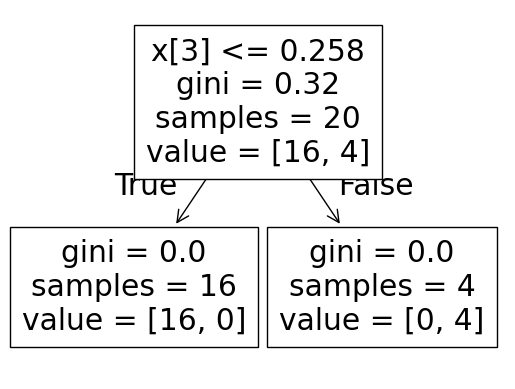

In [302]:
plot_tree(clf1)

[Text(0.4, 0.875, 'x[3] <= -0.723\ngini = 0.5\nsamples = 20\nvalue = [10, 10]'),
 Text(0.2, 0.625, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.30000000000000004, 0.75, 'True  '),
 Text(0.6, 0.625, 'x[1] <= 0.805\ngini = 0.355\nsamples = 13\nvalue = [3, 10]'),
 Text(0.5, 0.75, '  False'),
 Text(0.4, 0.375, 'x[4] <= -2.603\ngini = 0.165\nsamples = 11\nvalue = [1, 10]'),
 Text(0.2, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.6, 0.125, 'gini = 0.0\nsamples = 10\nvalue = [0, 10]'),
 Text(0.8, 0.375, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]')]

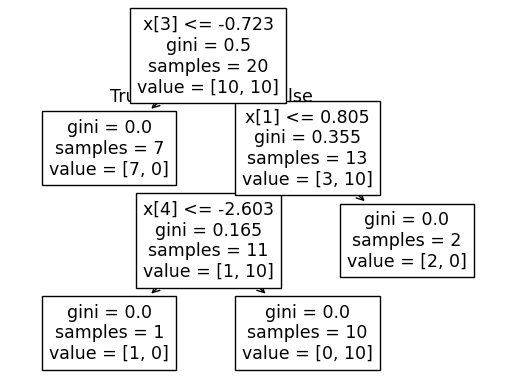

In [303]:
plot_tree(clf2)

[Text(0.6666666666666666, 0.875, 'x[3] <= 0.339\ngini = 0.48\nsamples = 20\nvalue = [8, 12]'),
 Text(0.5, 0.625, 'x[1] <= -0.809\ngini = 0.397\nsamples = 11\nvalue = [8, 3]'),
 Text(0.5833333333333333, 0.75, 'True  '),
 Text(0.3333333333333333, 0.375, 'x[1] <= -2.393\ngini = 0.375\nsamples = 4\nvalue = [1, 3]'),
 Text(0.16666666666666666, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.5, 0.125, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.6666666666666666, 0.375, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.8333333333333334, 0.625, 'gini = 0.0\nsamples = 9\nvalue = [0, 9]'),
 Text(0.75, 0.75, '  False')]

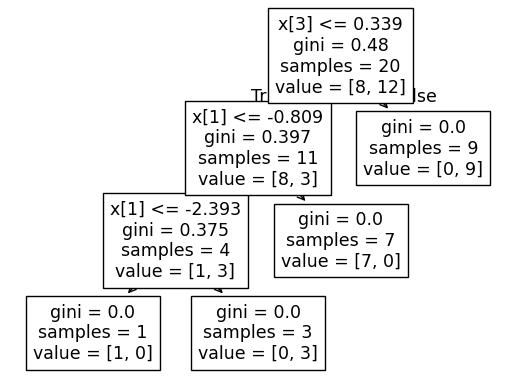

In [304]:
plot_tree(clf3)

### we will predict a random datapoint manually to see how the each Decision Tree is Predicting 


In [310]:
clf1.predict(np.array([-0.299745,	-0.347790,	-1.841516,	2.494107,	-0.930267]).reshape(1,5))

c:\Users\hb292\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [311]:
clf2.predict(np.array([-0.299745,	-0.347790,	-1.841516,	2.494107,	-0.930267]).reshape(1,5))

c:\Users\hb292\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [312]:
clf3.predict(np.array([-0.299745,	-0.347790,	-1.841516,	2.494107,	-0.930267]).reshape(1,5))

c:\Users\hb292\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

#### Query point Answer should be `1` so each tree predicted correctly